In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn wordcloud nltk textblob -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 67.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Training Dataset Shape
(74682, 4)
Validation Dataset Shape
(1000, 4)
     ID       Entity     Label  \
0  2401  Borderlands  Positive   
1  2401  Borderlands  Positive   
2  2401  Borderlands  Positive   
3  2401  Borderlands  Positive   
4  2401  Borderlands  Positive   

                                                Text  
0  im getting on borderlands and i will murder yo...  
1  I am coming to the borders and I will kill you...  
2  im getting on borderlands and i will kill you ...  
3  im coming on borderlands and i will murder you...  
4  im getting on borderlands 2 and

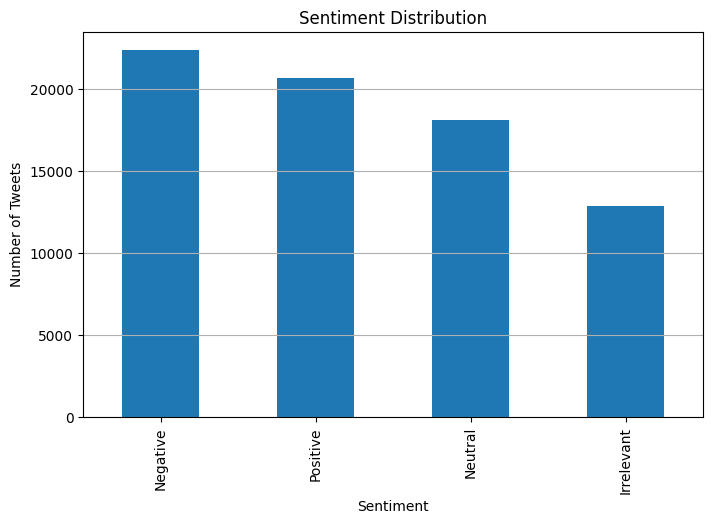


Loading spaCy Model...
spaCy Loaded Successfully

Processing Training Dataset...
Training Dataset Completed

Processing Validation Dataset...
Validation Dataset Completed

Encoded Labels
{'Irrelevant': np.int64(0), 'Negative': np.int64(1), 'Neutral': np.int64(2), 'Positive': np.int64(3)}

Training Samples : 59196
Testing Samples : 14800

Part 1 + Part 2 Completed Successfully


In [ ]:
# ============================================================
# TWITTER SENTIMENT ANALYSIS USING MACHINE LEARNING
# Professional Google Colab Version
# Developed for Academic Project
# ============================================================

# ============================
# STEP 1 : INSTALL LIBRARIES
# ============================

!pip -q install spacy
!python -m spacy download en_core_web_sm -q

# ============================
# STEP 2 : IMPORT LIBRARIES
# ============================

import warnings
warnings.filterwarnings("ignore")

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import spacy

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.pipeline import Pipeline

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ============================
# RANDOM SEED
# ============================

random.seed(42)
np.random.seed(42)

# ============================
# STEP 3 : LOAD DATASET
# ============================

columns = ["ID","Entity","Label","Text"]

train_df = pd.read_csv(
    "twitter_training.csv",
    names=columns
)

validation_df = pd.read_csv(
    "twitter_validation.csv",
    names=columns
)

print("="*60)
print("Training Dataset Shape")
print(train_df.shape)

print("="*60)
print("Validation Dataset Shape")
print(validation_df.shape)

print("="*60)
print(train_df.head())

# ============================
# STEP 4 : DATA CLEANING
# ============================

print("\nRemoving Missing Values...")

train_df.dropna(
    subset=["Text"],
    inplace=True
)

validation_df.dropna(
    subset=["Text"],
    inplace=True
)

train_df.reset_index(
    drop=True,
    inplace=True
)

validation_df.reset_index(
    drop=True,
    inplace=True
)

print("\nUpdated Shapes")

print(train_df.shape)
print(validation_df.shape)

# ============================
# STEP 5 : DATA INFORMATION
# ============================

print("\nDataset Information\n")

print(train_df.info())

print("\nLabel Distribution\n")

print(train_df["Label"].value_counts())

# ============================
# STEP 6 : DATA VISUALIZATION
# ============================

plt.figure(figsize=(8,5))

train_df["Label"].value_counts().plot(
    kind="bar"
)

plt.title("Sentiment Distribution")

plt.xlabel("Sentiment")

plt.ylabel("Number of Tweets")

plt.grid(axis="y")

plt.show()

# ============================
# STEP 7 : LOAD SPACY MODEL
# ============================

print("\nLoading spaCy Model...")

nlp = spacy.load(
    "en_core_web_sm",
    disable=["parser","ner"]
)

print("spaCy Loaded Successfully")

# ============================
# STEP 8 : TEXT PREPROCESSING
# ============================

def preprocess_batch(texts):

    processed_text=[]

    for doc in nlp.pipe(
        texts,
        batch_size=1000
    ):

        tokens=[]

        for token in doc:

            if token.is_stop:
                continue

            if token.is_punct:
                continue

            if token.like_num:
                continue

            tokens.append(
                token.lemma_.lower()
            )

        processed_text.append(
            " ".join(tokens)
        )

    return processed_text

# ============================
# STEP 9 : PREPROCESS TRAINING DATA
# ============================

print("\nProcessing Training Dataset...")

train_df["Processed_Text"] = preprocess_batch(
    train_df["Text"]
)

print("Training Dataset Completed")

# ============================
# STEP 10 : PREPROCESS VALIDATION DATA
# ============================

print("\nProcessing Validation Dataset...")

validation_df["Processed_Text"] = preprocess_batch(
    validation_df["Text"]
)

print("Validation Dataset Completed")

# ============================
# STEP 11 : LABEL ENCODING
# ============================

encoder = LabelEncoder()

train_df["Label"] = encoder.fit_transform(
    train_df["Label"]
)

validation_df["Label"] = encoder.transform(
    validation_df["Label"]
)

print("\nEncoded Labels")

print(
    dict(
        zip(
            encoder.classes_,
            encoder.transform(
                encoder.classes_
            )
        )
    )
)

# ============================
# STEP 12 : TRAIN TEST SPLIT
# ============================

X_train, X_test, y_train, y_test = train_test_split(

    train_df["Processed_Text"],

    train_df["Label"],

    test_size=0.20,

    random_state=42,

    stratify=train_df["Label"]

)

print("\nTraining Samples :",len(X_train))

print("Testing Samples :",len(X_test))

print("\nPart 1 + Part 2 Completed Successfully")

# ===================================================
# END OF PART 1 + PART 2
# Continue with Part 3 + Part 4
# ===================================================

TRAINING NAIVE BAYES MODEL

Naive Bayes Accuracy :
0.6346621621621622

Classification Report

              precision    recall  f1-score   support

  Irrelevant       0.72      0.35      0.47      2575
    Negative       0.62      0.80      0.70      4472
     Neutral       0.66      0.53      0.59      3622
    Positive       0.62      0.72      0.67      4131

    accuracy                           0.63     14800
   macro avg       0.65      0.60      0.61     14800
weighted avg       0.65      0.63      0.62     14800

TRAINING RANDOM FOREST MODEL

Random Forest Accuracy :
0.6147297297297297

Classification Report

              precision    recall  f1-score   support

  Irrelevant       0.98      0.15      0.26      2575
    Negative       0.51      0.92      0.66      4472
     Neutral       0.80      0.52      0.63      3622
    Positive       0.68      0.66      0.67      4131

    accuracy                           0.61     14800
   macro avg       0.74      0.56      0.55    

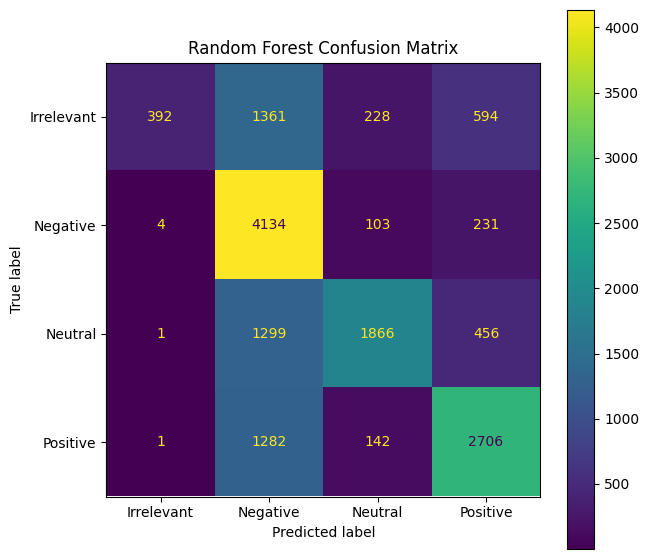

VALIDATION ACCURACY
0.711

Validation Classification Report

              precision    recall  f1-score   support

  Irrelevant       1.00      0.35      0.52       172
    Negative       0.57      0.94      0.71       266
     Neutral       0.85      0.67      0.75       285
    Positive       0.77      0.76      0.76       277

    accuracy                           0.71      1000
   macro avg       0.80      0.68      0.68      1000
weighted avg       0.78      0.71      0.70      1000

CUSTOM TWEET PREDICTION


In [ ]:
# ============================================================
# PART 3 : NAIVE BAYES MODEL
# ============================================================

print("="*60)
print("TRAINING NAIVE BAYES MODEL")
print("="*60)

nb_model = Pipeline([

    (
        "tfidf",
        TfidfVectorizer(
            max_features=5000,
            ngram_range=(1,2),
            min_df=2
        )
    ),

    (
        "naive_bayes",
        MultinomialNB()
    )

])

nb_model.fit(
    X_train,
    y_train
)

nb_prediction = nb_model.predict(
    X_test
)

print("\nNaive Bayes Accuracy :")

print(
    accuracy_score(
        y_test,
        nb_prediction
    )
)

print("\nClassification Report\n")

print(

    classification_report(

        y_test,

        nb_prediction,

        target_names=encoder.classes_

    )

)

# ============================================================
# PART 4 : RANDOM FOREST MODEL
# ============================================================

print("="*60)
print("TRAINING RANDOM FOREST MODEL")
print("="*60)

rf_model = Pipeline([

    (

        "tfidf",

        TfidfVectorizer(

            max_features=5000,

            ngram_range=(1,2),

            min_df=2

        )

    ),

    (

        "random_forest",

        RandomForestClassifier(

            n_estimators=100,

            max_depth=40,

            random_state=42,

            n_jobs=-1

        )

    )

])

rf_model.fit(

    X_train,

    y_train

)

rf_prediction = rf_model.predict(

    X_test

)

print("\nRandom Forest Accuracy :")

print(

    accuracy_score(

        y_test,

        rf_prediction

    )

)

print("\nClassification Report\n")

print(

    classification_report(

        y_test,

        rf_prediction,

        target_names=encoder.classes_

    )

)

# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(

    y_test,

    rf_prediction

)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=encoder.classes_

)

fig, ax = plt.subplots(figsize=(7,7))

disp.plot(ax=ax)

plt.title("Random Forest Confusion Matrix")

plt.show()

# ============================================================
# VALIDATION DATASET
# ============================================================

validation_prediction = rf_model.predict(

    validation_df["Processed_Text"]

)

validation_accuracy = accuracy_score(

    validation_df["Label"],

    validation_prediction

)

print("="*60)

print("VALIDATION ACCURACY")

print("="*60)

print(validation_accuracy)

print("\nValidation Classification Report\n")

print(

    classification_report(

        validation_df["Label"],

        validation_prediction,

        target_names=encoder.classes_

    )

)

# ============================================================
# SAMPLE PREDICTION
# ============================================================

print("="*60)
print("CUSTOM TWEET PREDICTION")
print("="*60)

sample = input("Enter Tweet : ")

sample_processed = preprocess_batch([sample])

prediction = rf_model.predict(

    sample_processed

)

predicted_label = encoder.inverse_transform(

    prediction

)

print("\nPredicted Sentiment :")

print(predicted_label[0])

# ============================================================
# MODEL COMPARISON
# ============================================================

nb_accuracy = accuracy_score(
    y_test,
    nb_prediction
)

rf_accuracy = accuracy_score(
    y_test,
    rf_prediction
)

comparison = pd.DataFrame({

    "Model":[

        "Naive Bayes",

        "Random Forest"

    ],

    "Accuracy":[

        nb_accuracy,

        rf_accuracy

    ]

})

print("\nModel Comparison\n")

print(comparison)

comparison.plot(

    x="Model",

    y="Accuracy",

    kind="bar",

    legend=False,

    figsize=(6,4)

)

plt.ylabel("Accuracy")

plt.title("Model Accuracy Comparison")

plt.grid(axis="y")

plt.show()

print("="*60)
print("PROJECT EXECUTED SUCCESSFULLY")
print("="*60)